In [1]:
import os, sys
sys.path.append(os.path.abspath("F:/Neutrino_SI/Pycode"))  # 让 Python 能找到该目录的模块
print("cwd:", os.getcwd())
print("has project root in sys.path?", any("Neutrino_SI" in p for p in sys.path))

cwd: f:\Neutrino_SI
has project root in sys.path? True


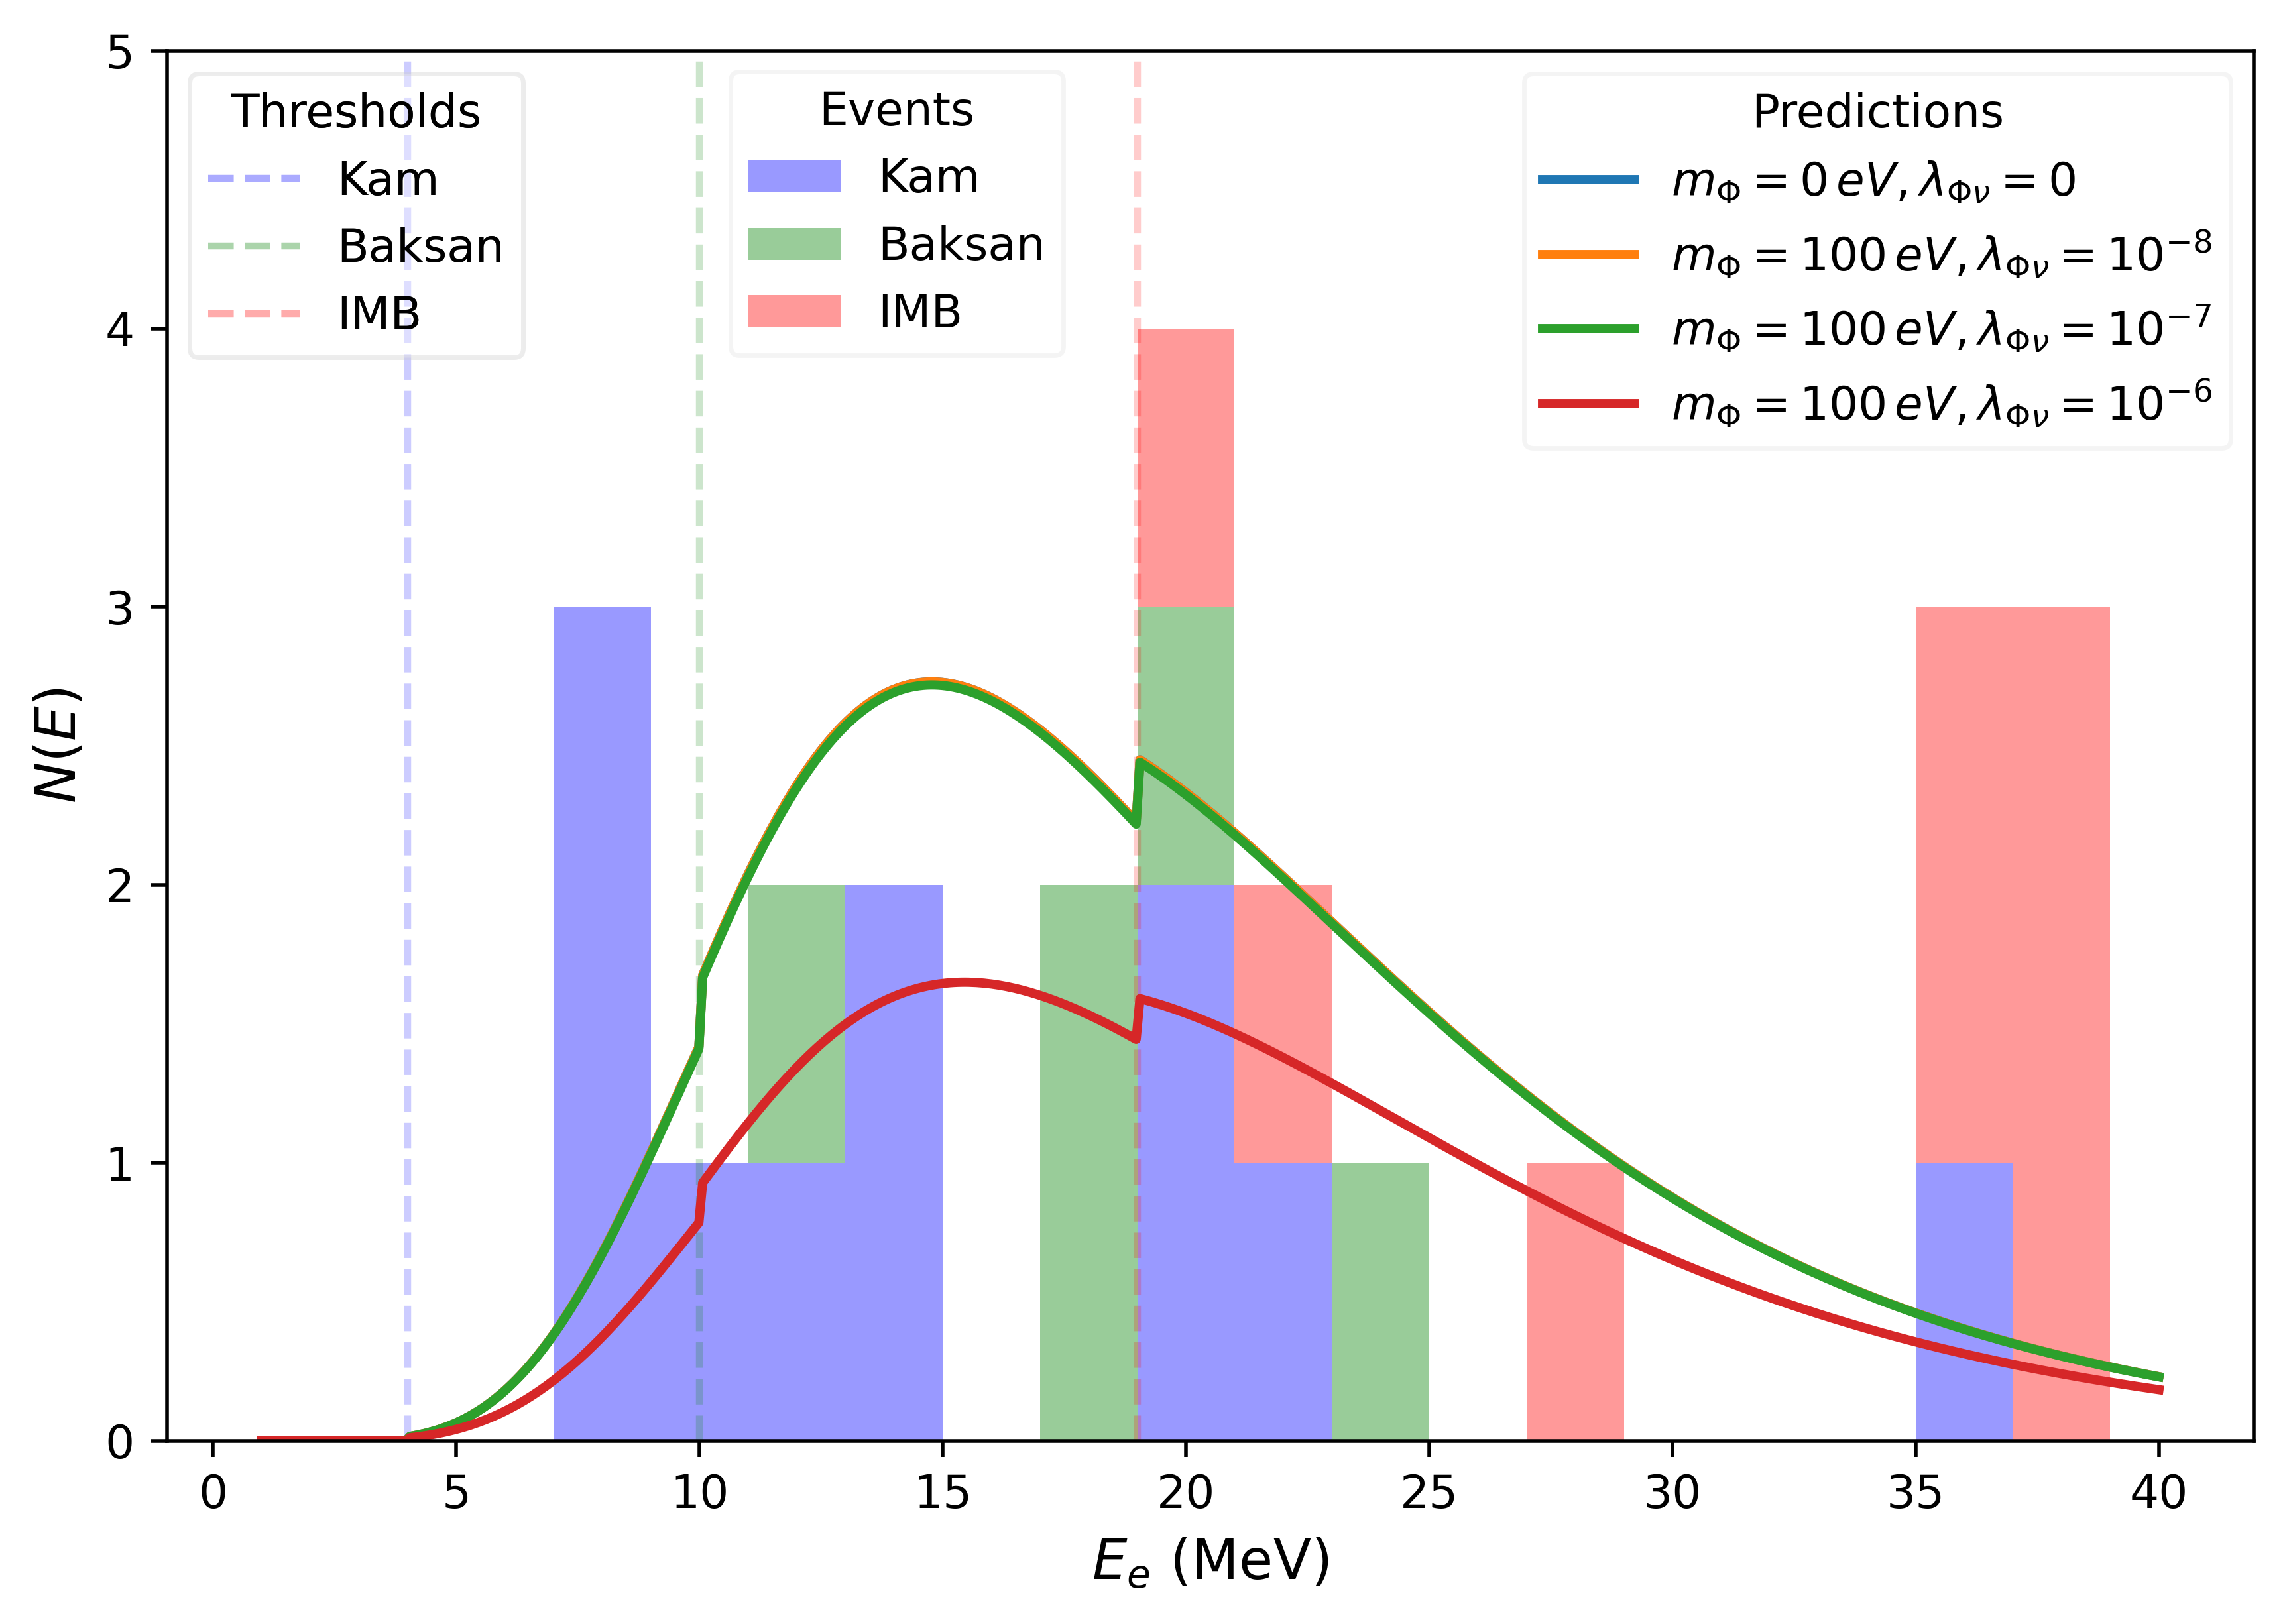

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from Pycode import SignalRate
from Pycode import Data
from Pycode import definition as df


# --- 理论模型 SignalRate ---

fix_0 = [13.75, 4.90, 4.74, 0.17, 2.33, 0.54, 0, 0]
fix_1 = [13.75, 4.90, 4.74, 0.17, 2.33, 0.54, 100, 1]  # best fit six-parameter
fix_2 = [13.75, 4.90, 4.74, 0.17, 2.33, 0.54, 100, 10]
fix_3 = [13.75, 4.90, 4.74, 0.17, 2.33, 0.54, 100, 100]

# fix_3 = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 100, 50]

E_hist = np.concatenate((Data.Kam_E, Data.IMB_E, Data.Baksan_E), axis=0)
dE_hist = np.concatenate((Data.Kam_dE, Data.IMB_dE, Data.Baksan_dE), axis=0)

# n_mc = 100  # 每个点采样次数
# samples = np.hstack([
#     np.random.normal(E, dE, n_mc) for E, dE in zip(E_hist, dE_hist)
# ])
Ex = np.linspace(1,40,500)

def SR_E(c, t, E, *theta):

    return (np.where(E<=4, 0, SignalRate.SR_K(t, E, c, *theta))
            +np.where(E<=19, 0, SignalRate.SR_I(t, E, c, *theta))
            +np.where(E<=10, 0, SignalRate.SR_B(t, E, c, *theta)))

def SR_E_K(c, t, E, *theta):

    return np.where(E<=4, 0, SignalRate.SR_K(t, E, c, *theta))
       
def SR_E_B(c, t, E, *theta):

    return np.where(E<=10, 0, SignalRate.SR_B(t, E, c, *theta))

def SR_E_I(c, t, E, *theta):

    return np.where(E<=19, 0, SignalRate.SR_I(t, E, c, *theta))

yx_E_0 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_0)
yx_E_1 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_1)
yx_E_2 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_2)
yx_E_3 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_3)

# yx_E_3 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_3)

counts, bin_edges = np.histogram(E_hist, bins=np.arange(Ex[0], Ex[-1], 2))
bin_width = bin_edges[1] - bin_edges[0]
area_hist = np.sum(counts * bin_width)  
area_func = np.trapezoid(yx_E_0, Ex)  
scale_factor = area_hist / area_func

# --- 绘图 ---
fig, ax = plt.subplots(figsize=(7,5),dpi = 500)

# 理论曲线
v1 = ax.axvline(x=4, label='Kam threshold', ls='--', color='blue', alpha=0.2)
v2 = ax.axvline(x=10, label='Baksan threshold',ls='--', color='green', alpha=0.2)
v3 = ax.axvline(x=19, label='IMB threshold', ls='--', color='red', alpha=0.2)

line1, = ax.plot(Ex, yx_E_0*scale_factor, lw=2, label=r'$m_{\Phi}=0eV,\lambda_{\Phi\nu}=0$')
line2, = ax.plot(Ex, yx_E_1*scale_factor, lw=2, label=r'$m_{\Phi}=100eV,\lambda_{\Phi\nu}=10^{-8}$')
line3, = ax.plot(Ex, yx_E_2*scale_factor, lw=2, label=r'$m_{\Phi}=100eV,\lambda_{\Phi\nu}=10^{-7}$')
line4, = ax.plot(Ex, yx_E_3*scale_factor, lw=2, label=r'$m_{\Phi}=100eV,\lambda_{\Phi\nu}=10^{-6}$')

# ax.plot(Ex, yx_E_2*scale_factor, label=r'fit2 with resonance: $m/eV=420,\lambda_{\Phi\nu}/10^{-8}=108$', lw=2)

# ax.plot(Ex, yx_E_3*scale_factor, label=r'asm: $m/eV=100,\lambda_{\Phi\nu}/10^{-8}=50$', lw=2)

counts, bins_hist, patches = ax.hist(
    [Data.Kam_E, Data.Baksan_E, Data.IMB_E],
    bins=np.arange(Ex[0], Ex[-1], 2),
    stacked=True,          
    # label=["Kamiokande", "IMB", "Baksan"],
    color=['blue', 'green', 'red'],
    alpha=0.4             
)

leg1 = ax.legend(patches,
                 ['Kam', 'Baksan', 'IMB'],
                  loc="upper left",
                  bbox_to_anchor=(0.27, 0.985),
                  borderaxespad=0.,
                  title ="Events",
                  framealpha=0.2)
ax.add_artist(leg1)

# (2) line legend
leg2 = ax.legend([line1, line2, line3, line4],
                 [r'$m_{\Phi}=0\,eV,\lambda_{\Phi\nu}=0$',
                  r'$m_{\Phi}=100\,eV,\lambda_{\Phi\nu}=10^{-8}$',
                  r'$m_{\Phi}=100\,eV,\lambda_{\Phi\nu}=10^{-7}$',
                  r'$m_{\Phi}=100\,eV,\lambda_{\Phi\nu}=10^{-6}$'],
                 loc="upper right", 
                 framealpha=0.2,
                 title ="Predictions")
ax.add_artist(leg2)

# (3) vertical line legend
leg3 = ax.legend([v1, v2, v3],
                 ['Kam', 'Baksan', 'IMB'],
                 loc="upper left",
                 framealpha=0.2,
                 title = 'Thresholds')
ax.add_artist(leg3)

ax.set_xlabel(r"$E_e$ (MeV)", fontsize=12)
ax.set_ylabel("$N(E)$", fontsize=12)

ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

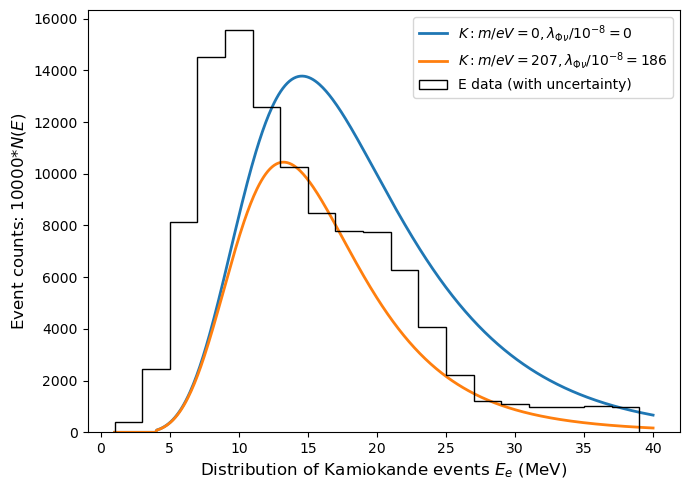

In [14]:
E_hist_K = Data.Kam_E
dE_hist_K = Data.Kam_dE
n_mc=10000
fix_0 = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 0, 0]

samples = np.hstack([
    np.random.normal(E, dE, n_mc) for E, dE in zip(E_hist_K, dE_hist_K)
])

fix_K = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 207, 186]

yx_E_K_0 = df.gl2_integrate_vec(SR_E_K,  [(-1, 1),(0, 30)], Ex, args=fix_0)
yx_E_K_1 = df.gl2_integrate_vec(SR_E_K,  [(-1, 1),(0, 30)], Ex, args=fix_K)

counts, bin_edges = np.histogram(samples, bins=np.arange(Ex[0], Ex[-1], 2))
bin_width = bin_edges[1] - bin_edges[0]
area_hist = np.sum(counts * bin_width)  
area_func = np.trapezoid(yx_E_K_0, Ex)  
scale_factor = area_hist / area_func

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(Ex, yx_E_K_0*scale_factor, label=r'$K: m/eV=0,\lambda_{\Phi\nu}/10^{-8}=0$', lw=2)
ax.plot(Ex, yx_E_K_1*scale_factor, label=r'$K: m/eV=207,\lambda_{\Phi\nu}/10^{-8}=186$', lw=2)

counts, bins, patches = ax.hist(samples, bins=np.arange(Ex[0], Ex[-1], 2),
                                histtype='step', color='black',
                                label='E data (with uncertainty)')

ax.set_xlabel(r"Distribution of Kamiokande events $E_e$ (MeV)", fontsize=12)
ax.set_ylabel("Event counts: " +str(n_mc)+"*$N(E)$", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

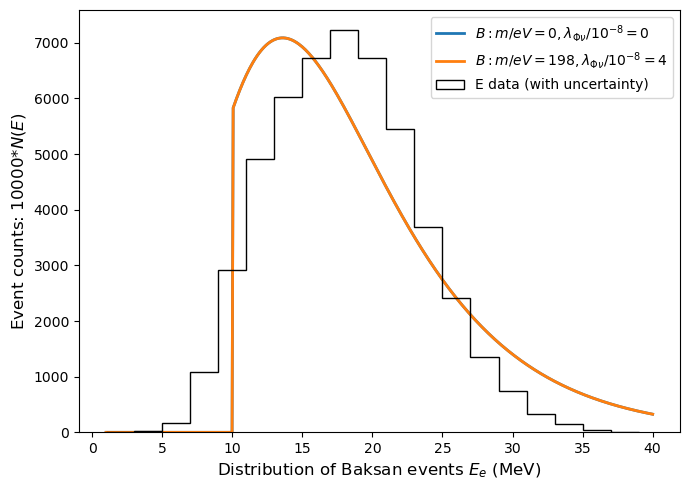

In [15]:
E_hist_B = Data.Baksan_E
dE_hist_B = Data.Baksan_dE

samples = np.hstack([
    np.random.normal(E, dE, n_mc) for E, dE in zip(E_hist_B, dE_hist_B)
])


fix_B = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 198, 3.66]

yx_E_B_0 = df.gl2_integrate_vec(SR_E_B,  [(-1, 1),(0, 30)], Ex, args=fix_0)
yx_E_B_1 = df.gl2_integrate_vec(SR_E_B,  [(-1, 1),(0, 30)], Ex, args=fix_B)

counts, bin_edges = np.histogram(samples, bins=np.arange(Ex[0], Ex[-1], 2))
bin_width = bin_edges[1] - bin_edges[0]
area_hist = np.sum(counts * bin_width)  
area_func = np.trapezoid(yx_E_B_0, Ex)  
scale_factor = area_hist / area_func

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(Ex, yx_E_B_0*scale_factor, label=r'$B: m/eV=0,\lambda_{\Phi\nu}/10^{-8}=0$', lw=2)
ax.plot(Ex, yx_E_B_1*scale_factor, label=r'$B: m/eV=198,\lambda_{\Phi\nu}/10^{-8}=4$', lw=2)

counts, bins, patches = ax.hist(samples, bins=np.arange(Ex[0], Ex[-1], 2),
                                histtype='step', color='black',
                                label='E data (with uncertainty)')

ax.set_xlabel(r"Distribution of Baksan events $E_e$ (MeV)", fontsize=12)
ax.set_ylabel("Event counts: " +str(n_mc)+"*$N(E)$", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

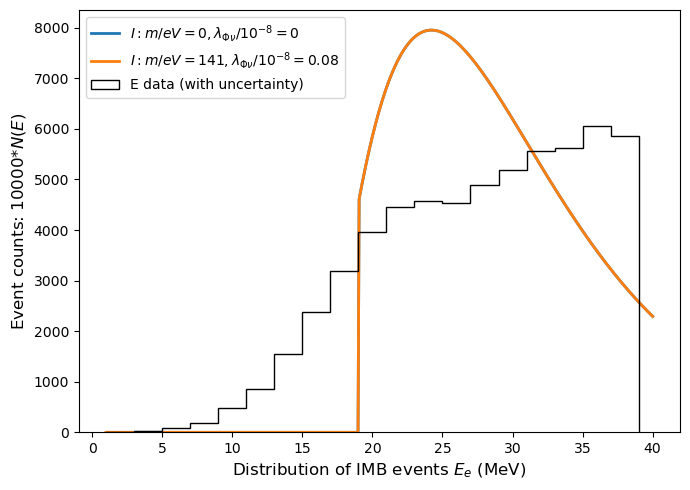

In [16]:
E_hist_I = Data.IMB_E
dE_hist_I = Data.IMB_dE

samples = np.hstack([
    np.random.normal(E, dE, n_mc) for E, dE in zip(E_hist_I, dE_hist_I)
])

fix_I = [12.597, 5.036, 4.688, 0.291, 2.179, 0.527, 141, 0.08]

yx_E_I_0 = df.gl2_integrate_vec(SR_E_I,  [(-1, 1),(0, 30)], Ex, args=fix_0)
yx_E_I_1 = df.gl2_integrate_vec(SR_E_I,  [(-1, 1),(0, 30)], Ex, args=fix_I)

counts, bin_edges = np.histogram(samples, bins=np.arange(Ex[0], Ex[-1], 2))
bin_width = bin_edges[1] - bin_edges[0]
area_hist = np.sum(counts * bin_width)  
area_func = np.trapezoid(yx_E_I_0, Ex)  
scale_factor = area_hist / area_func

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(Ex, yx_E_I_0*scale_factor, label=r'$I: m/eV=0,\lambda_{\Phi\nu}/10^{-8}=0$', lw=2)
ax.plot(Ex, yx_E_I_1*scale_factor, label=r'$I: m/eV=141,\lambda_{\Phi\nu}/10^{-8}=0.08$', lw=2)

counts, bins, patches = ax.hist(samples, bins=np.arange(Ex[0], Ex[-1], 2),
                                histtype='step', color='black',
                                label='E data (with uncertainty)')

ax.set_xlabel(r"Distribution of IMB events $E_e$ (MeV)", fontsize=12)
ax.set_ylabel("Event counts: " +str(n_mc)+"*$N(E)$", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

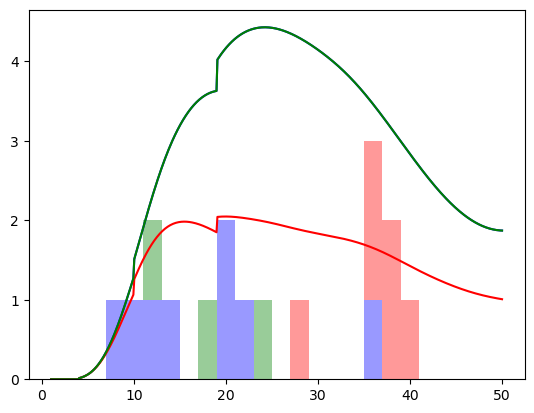

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from Pycode import SignalRate_2d
from Pycode import Data
from Pycode import definition as df

fix_0 = [None, None, None, None, None, None, 0, -8]
fix_1 = [None, None, None, None, None, None, 2.29, -5.61]
fix_2 = [None, None, None, None, None, None, 3, -4.5]

def SR_E(c, t, E, *theta):

    return (np.where(E<=4, 0, SignalRate_2d.SR_K(t, E, c, *theta))
            +np.where(E<=19, 0, SignalRate_2d.SR_I(t, E, c, *theta))
            +np.where(E<=10, 0, SignalRate_2d.SR_B(t, E, c, *theta)))

def SR_E_K(c, t, E, *theta):

    return np.where(E<=4, 0, SignalRate_2d.SR_K(t, E, c, *theta))
       
def SR_E_B(c, t, E, *theta):

    return np.where(E<=10, 0, SignalRate_2d.SR_B(t, E, c, *theta))

def SR_E_I(c, t, E, *theta):

    return np.where(E<=19, 0, SignalRate_2d.SR_I(t, E, c, *theta))

Ex = np.linspace(1,50,500)

yx_E_0 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_0)
yx_E_1 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_1)
yx_E_2 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_2)

fig, ax = plt.subplots()

counts, bins_hist, patches = ax.hist(
    [Data.Kam_E, Data.Baksan_E, Data.IMB_E],
    bins=np.arange(Ex[0], Ex[-1], 2),
    stacked=True,          
    # label=["Kamiokande", "IMB", "Baksan"],
    color=['blue', 'green', 'red'],
    alpha=0.4             
)

plt.plot(Ex, yx_E_0, color='blue')
plt.plot(Ex, yx_E_1, color='red')
plt.plot(Ex, yx_E_2, color='green')
